In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# eliminam formatul stiintific pentru probabilitati
np.set_printoptions(suppress=True)

# incarcam datele
df = pd.read_csv('data/Teen_Mental_Health_Dataset.csv')

# eliminam atributele stress_level, anxiety_level si addiction_level
df = df.drop(['stress_level', 'anxiety_level', 'addiction_level'], axis=1)

# transformam variabile text in numerice
def encode_text(df, columns):
    le = LabelEncoder()
    for col in columns:
        df[col] = le.fit_transform(df[col])
    return df

categoriale = ['gender', 'platform_usage', 'social_interaction_level']
df = encode_text(df, categoriale)

# separare X (atribute) si y (scop)
X = df.drop('depression_label', axis=1).values.astype(np.float32)
y = df['depression_label'].values.astype(np.float32)

# standardizam datele
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# functie pentru rularea experimentului SVM
def experiment_svm(k_fold_val, kernel_val, C_val, gamma_val, prob_val, nume_exp):
    print(f"\n\n--- {nume_exp} ---")
    print(f"Parametri: Kernel={kernel_val}, C={C_val}, Gamma={gamma_val}, Probability={prob_val}")
    
    # construirea modelului SVM 
    svm_model = SVC(kernel=kernel_val, C=C_val, gamma=gamma_val, probability=prob_val, random_state=1)
    kf = KFold(n_splits=k_fold_val, shuffle=True, random_state=42)
    
    # predictiile modelului prin k-fold 
    y_pred = cross_val_predict(svm_model, X_std, y, cv=kf)
    
    # afisarea numarului de instante
    n_test = len(y)
    print("Numarul de instante noi =", n_test)

    # calcularea erorii de predictie ca raport
    n_pred_incorect = (y != y_pred).sum()
    print("Eroarea de predictie : % 5.2f" % (n_pred_incorect / n_test))

    # acuratetea de predictie
    print("Acuratetea este % 5.2f" % accuracy_score(y, y_pred))
    
    # daca am setat probability=True, afisam si probabilitatile
    if prob_val:
        y_proba = cross_val_predict(svm_model, X_std, y, cv=kf, method='predict_proba')
        print('Probabilitatile ptr. primele 5 instante test (%):\n', y_proba[:5] * 100)

    # afisare raport de clasificare
    print("\nRaportul de clasificare:")
    print(classification_report(y, y_pred))
    
    # matricea de confuzie
    cm = confusion_matrix(y, y_pred)
    print('Matricea de confuzie:\n', cm)
    
    # reprezentare grafica
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # matricea de confuzie grafica
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax[0], cmap='Purples')
    ax[0].set_title(f"Matrice Confuzie {nume_exp}")
    
    # comparare valori reale vs predictii (esantion 50 instante)
    t = pd.DataFrame({'real': y[:50], 'predit': y_pred[:50]})
    ax[1].plot(t['real'].tolist(), label='Real', marker='o', linestyle='')
    ax[1].plot(t['predit'].tolist(), label='Predit', marker='x', linestyle='')
    ax[1].set_title("Real vs Predictie SVM")
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()



--- Exp_SVM_1 ---
Parametri: Kernel=linear, C=1.0, Gamma=scale, Probability=True
Numarul de instante noi = 1200
Eroarea de predictie :  0.03
Acuratetea este  0.97
Probabilitatile ptr. primele 5 instante test (%):
 [[97.5751114   2.4248886 ]
 [99.26392418  0.73607582]
 [98.42399408  1.57600592]
 [91.30011864  8.69988136]
 [95.57116653  4.42883347]]

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


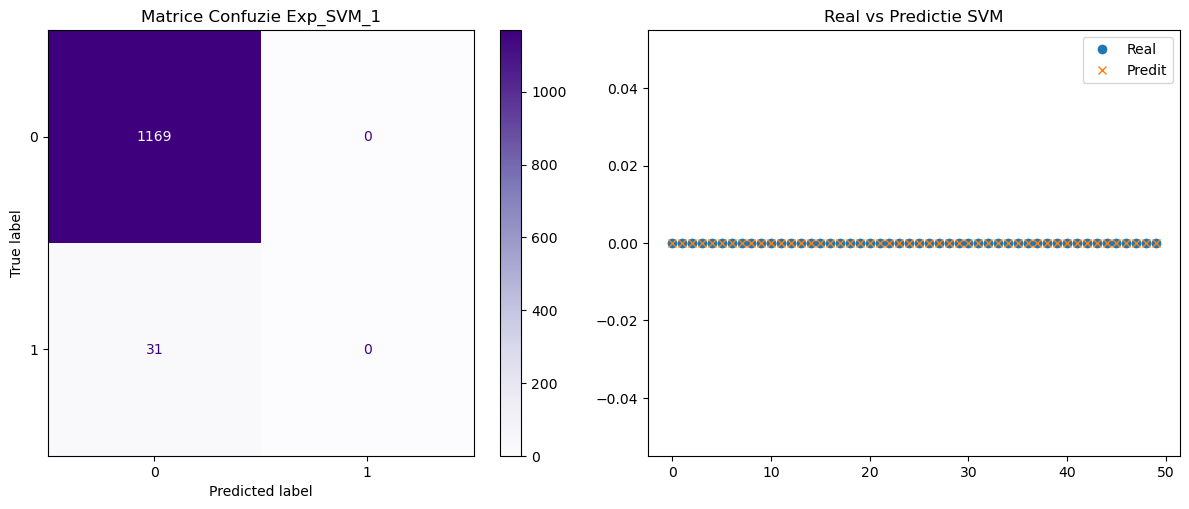

In [2]:
# experiment 1
experiment_svm(k_fold_val=5, kernel_val='linear', C_val=1.0, gamma_val='scale', prob_val=True, nume_exp="Exp_SVM_1")



--- Exp_SVM_1 ---
Parametri: Kernel=rbf, C=0.1, Gamma=scale, Probability=True
Numarul de instante noi = 1200
Eroarea de predictie :  0.03
Acuratetea este  0.97
Probabilitatile ptr. primele 5 instante test (%):
 [[97.74162413  2.25837587]
 [98.90638785  1.09361215]
 [98.41997984  1.58002016]
 [98.42147313  1.57852687]
 [94.07506397  5.92493603]]

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


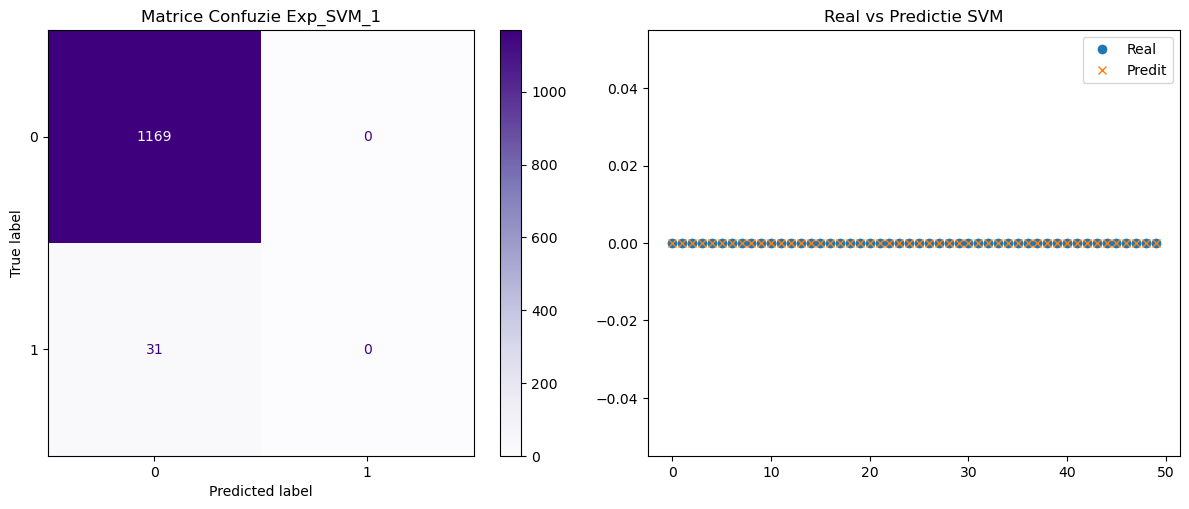

In [3]:
# experiment 2
experiment_svm(k_fold_val=5, kernel_val='rbf', C_val=0.1, gamma_val='scale', prob_val=True, nume_exp="Exp_SVM_1")



--- Exp_SVM_3 ---
Parametri: Kernel=rbf, C=10.0, Gamma=scale, Probability=True
Numarul de instante noi = 1200
Eroarea de predictie :  0.04
Acuratetea este  0.96
Probabilitatile ptr. primele 5 instante test (%):
 [[98.0996153   1.9003847 ]
 [99.28011483  0.71988517]
 [98.63846704  1.36153296]
 [98.51825868  1.48174132]
 [92.84642066  7.15357934]]

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.98      0.99      0.98      1169
         1.0       0.12      0.06      0.09        31

    accuracy                           0.96      1200
   macro avg       0.55      0.53      0.53      1200
weighted avg       0.95      0.96      0.96      1200

Matricea de confuzie:
 [[1155   14]
 [  29    2]]


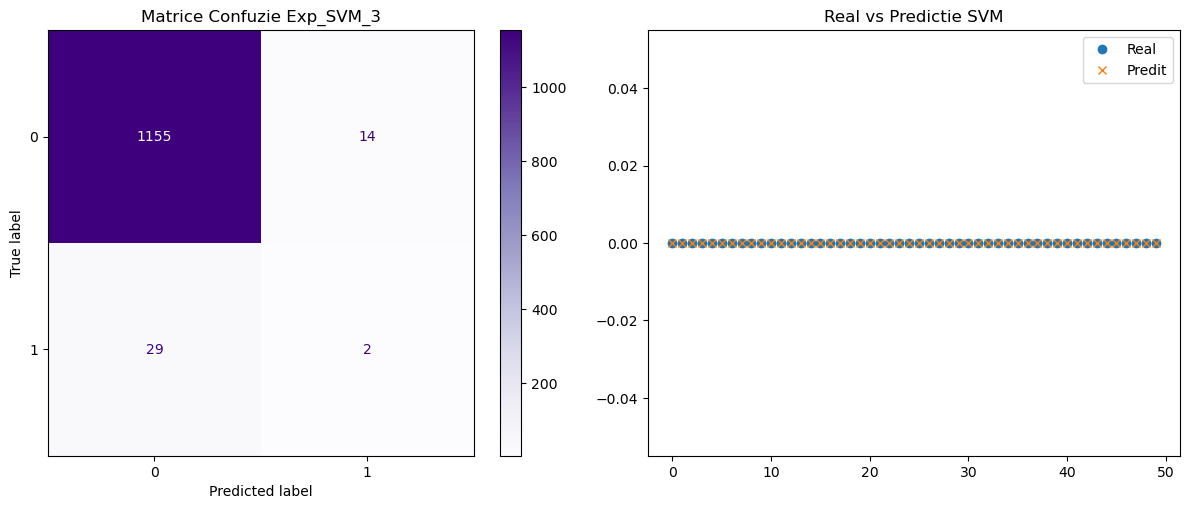

In [4]:
# experiment 3
experiment_svm(k_fold_val=5, kernel_val='rbf', C_val=10.0, gamma_val='scale', prob_val=True, nume_exp="Exp_SVM_3")



--- Exp_SVM_4 ---
Parametri: Kernel=poly, C=1.0, Gamma=scale, Probability=True
Numarul de instante noi = 1200
Eroarea de predictie :  0.03
Acuratetea este  0.97
Probabilitatile ptr. primele 5 instante test (%):
 [[97.84375697  2.15624303]
 [98.4812649   1.5187351 ]
 [99.46612403  0.53387597]
 [97.74815202  2.25184798]
 [96.21825022  3.78174978]]

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


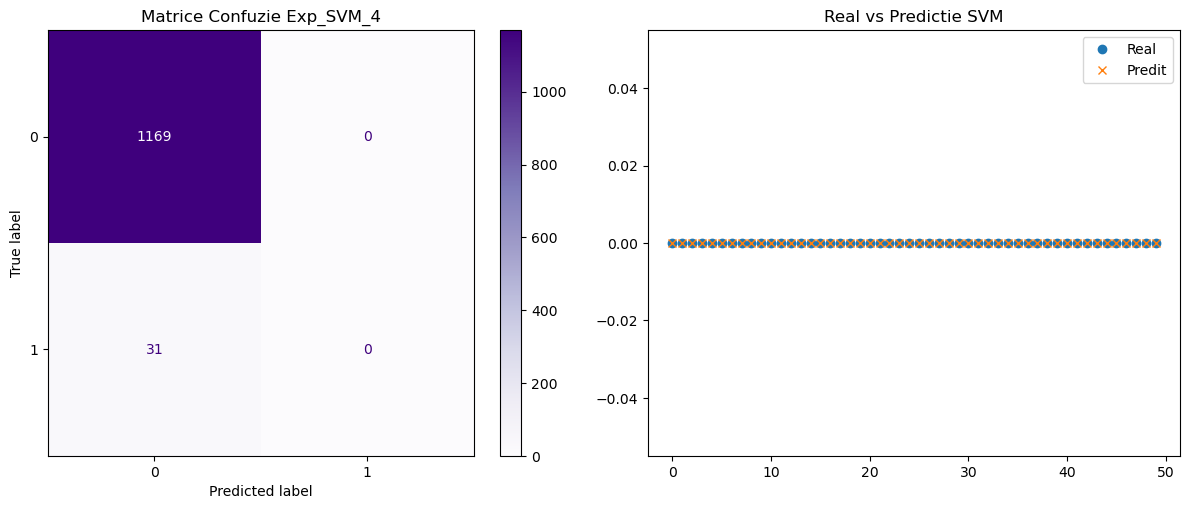

In [5]:
# experiment 4
experiment_svm(k_fold_val=5, kernel_val='poly', C_val=1.0, gamma_val='scale', prob_val=True, nume_exp="Exp_SVM_4")



--- Exp_SVM_5 ---
Parametri: Kernel=rbf, C=1.0, Gamma=auto, Probability=True
Numarul de instante noi = 1200
Eroarea de predictie :  0.03
Acuratetea este  0.97
Probabilitatile ptr. primele 5 instante test (%):
 [[98.29815134  1.70184866]
 [99.21966974  0.78033026]
 [98.26123656  1.73876344]
 [98.30145992  1.69854008]
 [94.52236794  5.47763206]]

Raportul de clasificare:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      1169
         1.0       0.00      0.00      0.00        31

    accuracy                           0.97      1200
   macro avg       0.49      0.50      0.49      1200
weighted avg       0.95      0.97      0.96      1200

Matricea de confuzie:
 [[1169    0]
 [  31    0]]


C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\emanu\anaconda3\envs\tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


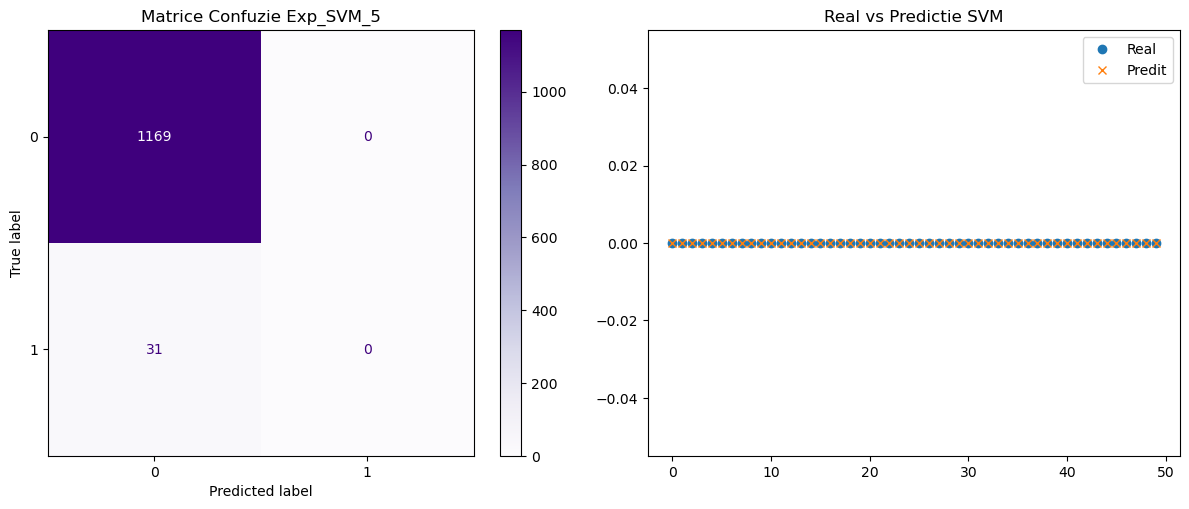

In [6]:
# experiment 5
experiment_svm(k_fold_val=10, kernel_val='rbf', C_val=1.0, gamma_val='auto', prob_val=True, nume_exp="Exp_SVM_5")